# Graph Initialization

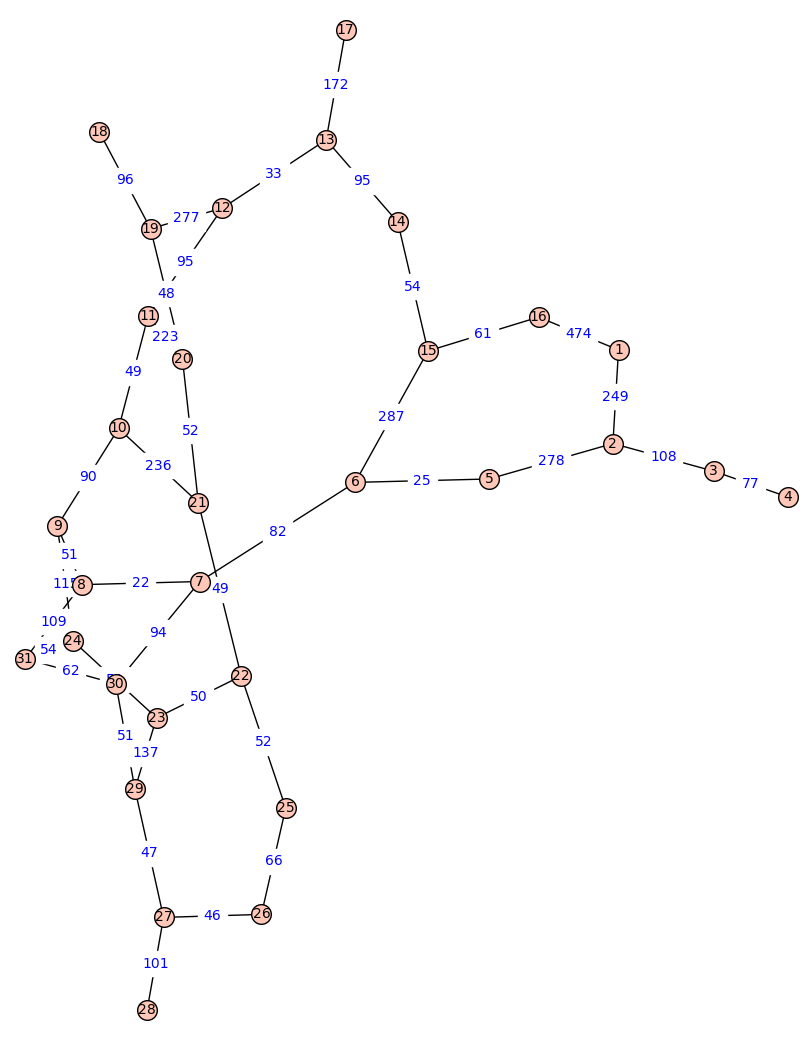

In [1]:
G = Graph([(1,2,249),(2,3,108),(3,4,77),(2,5,278),(1,16,474),(5,6,25),(6,15,287),(15,16,61),(6,7,82),(7,8,22),(7,30,94),(30,29,51),(29,27,47),(28,27,101),(27,26,46),(26,25,66),(25,22,52),(29,23,137),(30,31,62),(31,24,54),(8,9,51),(31,8,109),(24,9,115),(9,10,90),(22,21,49),(21,10,236),(21,20,52),(10,11,49),(20,11,223),(20,19,48),(11,12,95),(12,13,33),(19,12,277),(18,19,96),(17,13,172),(13,14,95),(14,15,54),(22,23,50),(24,23,50)])

G.show(edge_labels=True, figsize=14)

In [2]:
G.shortest_path(2,4,check_weight=True)
cost = G.shortest_path_length(2, 4, by_weight=True)
cost

185

### Initial Eulerian Check

In [3]:
# Check if the Graph is Eulerian for the Chinese Postman Problem
G.is_eulerian()

False

### Checking for Odd-Degree Vertices

In [4]:
# Lists the Adjacency Matrix of G
Adj = G.adjacency_matrix()
Adj.str()

'[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]\n[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]\n[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]\n[1 0 0 0 0 0 0 0 0 0 0 0

In [5]:
import numpy as np
Adj = np.array(Adj)
degrees = Adj.sum(axis=1)
vertex = 0
odd_vertices = []
for i in degrees:
    vertex += 1
    if i % 2 == 1:
        odd_vertices.append(vertex) # Adds that Vertex to the array if it is odd

odd_vertices = np.array(odd_vertices)
print("Odd Degree Vertices: ", len(odd_vertices))

Odd Degree Vertices:  24


In [6]:
# The Odd-Degree Vertices to be used
odd_vertices

array([ 2,  4,  6,  7,  8,  9, 10, 11, 12, 13, 15, 17, 18, 19, 20, 21, 22,
       23, 24, 27, 28, 29, 30, 31])

# ACO


In [7]:
# Gloaval Variables
alpha = 1
beta = 5
rho = 0.1
Q = 1
Tao = {}

# Initialixing Tao Matrix (2D Array)
for u in odd_vertices:
    for v in odd_vertices:
        if u != v:
            Tao[(u,v)] = 1

Best_Distance = 0
Best_Pairs = []
remaining_odds = odd_vertices

In [8]:
import numpy as np

# Eta
def eta():
    nums = []
    for i in range(len(remaining_odds)):
        cost = G.shortest_path_length(remaining_odds[0], remaining_odds[i], by_weight=True)
        nums.append(cost)
    return nums

In [9]:
# Numerators Summation
def summation():
    i = remaining_odds[0]  # current vertex
    total = 0
    
    for j in remaining_odds:
        if j == i:
            continue
        
        d = G.shortest_path_length(i, j, by_weight=True)
        total += (Tao[(i,j)] ** alpha) * (1/d) ** beta
    
    return total.n()
        
summation()

5.48564969195491e-12

In [10]:
def normalize():
    p = []
    i = remaining_odds[0]
    
    denom = 0
    for j in remaining_odds:
        if j == i:
            continue
        d = G.shortest_path_length(i, j, by_weight=True)
        denom += (Tao[(i,j)]**alpha) * (1/d)**beta

    for j in remaining_odds:
        if j == i:
            p.append(0)
            continue
        
        d = G.shortest_path_length(i, j, by_weight=True)
        num = (Tao[(i,j)]**alpha) * (1/d)**beta
        p.append(num / denom)
    
    return p

In [11]:
import random

def choose():
    probabilities = normalize()
    i = remaining_odds[0]
    
    r = random.random()
    cumulative = 0
    
    for j, p in enumerate(probabilities):
        cumulative += p
        if r <= cumulative:
            return i, remaining_odds[j]

In [12]:
def bestDistance():
    x, y = choose()
    Best_Distance = G.shortest_path_length(x, y, by_weight=True)
    return Best_Distance

In [13]:
def pheromone():
    global remaining_odds
    pairs = []
    
    while len(remaining_odds) > 1:
        x, y = choose()
        pairs.append((x,y))
        remaining_odds = [v for v in remaining_odds if v != x and v != y]
    
    return pairs

In [14]:
def update_pheromones(pairs):
    global Tao
    
    # Evaporation
    for edge in Tao:
        Tao[edge] *= (1 - rho)
    
    # Reinforcement
    for (u, v) in pairs:
        dist = G.shortest_path_length(u, v, by_weight=True)
        Tao[(u,v)] += Q / dist
        Tao[(v,u)] += Q / dist

In [15]:
for generation in range(10):
    remaining_odds = list(odd_vertices)
    
    pairs = pheromone()

    total_dist = 0

    for u, v in pairs:
        dist = G.shortest_path_length(u, v, by_weight=True)
        total_dist += dist
    
    update_pheromones(pairs)
    
    print(f"Generation {generation+1} | Total Distance: {total_dist}")
    for i in pairs:
        print(f"Pairs found: {i}")

Generation 1 | Total Distance: 2047
Pairs found: (np.int64(2), np.int64(4))
Pairs found: (np.int64(6), np.int64(8))
Pairs found: (np.int64(7), np.int64(9))
Pairs found: (np.int64(10), np.int64(11))
Pairs found: (np.int64(12), np.int64(13))
Pairs found: (np.int64(15), np.int64(24))
Pairs found: (np.int64(17), np.int64(21))
Pairs found: (np.int64(18), np.int64(19))
Pairs found: (np.int64(20), np.int64(22))
Pairs found: (np.int64(23), np.int64(29))
Pairs found: (np.int64(27), np.int64(28))
Pairs found: (np.int64(30), np.int64(31))
Generation 2 | Total Distance: 1263
Pairs found: (np.int64(2), np.int64(4))
Pairs found: (np.int64(6), np.int64(8))
Pairs found: (np.int64(7), np.int64(9))
Pairs found: (np.int64(10), np.int64(11))
Pairs found: (np.int64(12), np.int64(13))
Pairs found: (np.int64(15), np.int64(17))
Pairs found: (np.int64(18), np.int64(19))
Pairs found: (np.int64(20), np.int64(21))
Pairs found: (np.int64(22), np.int64(23))
Pairs found: (np.int64(24), np.int64(31))
Pairs found: (np

# Appending the Graph

In [16]:
# From the ACO (Best Pair with Distance 1219)
Best_Pairs = [(2,4),(6,7),(8,9),(10,11),(12,13),(15,17),(18,19),(20,21),(22,23),(24,31),(27,29),(28,30)]

In [17]:
Best_Pairs[1]

(6, 7)

In [18]:
I = Graph(G, multiedges=True)

In [19]:
for i in Best_Pairs:
    print(i[0], i[1])
    cost = G.shortest_path_length(i[0], i[1], by_weight=True)
    I.add_edge(i[0],i[1],cost)

print("Success")

2 4
6 7
8 9
10 11
12 13
15 17
18 19
20 21
22 23
24 31
27 29
28 30
Success


In [24]:
I.is_eulerian()

True

# Eulerian Graph


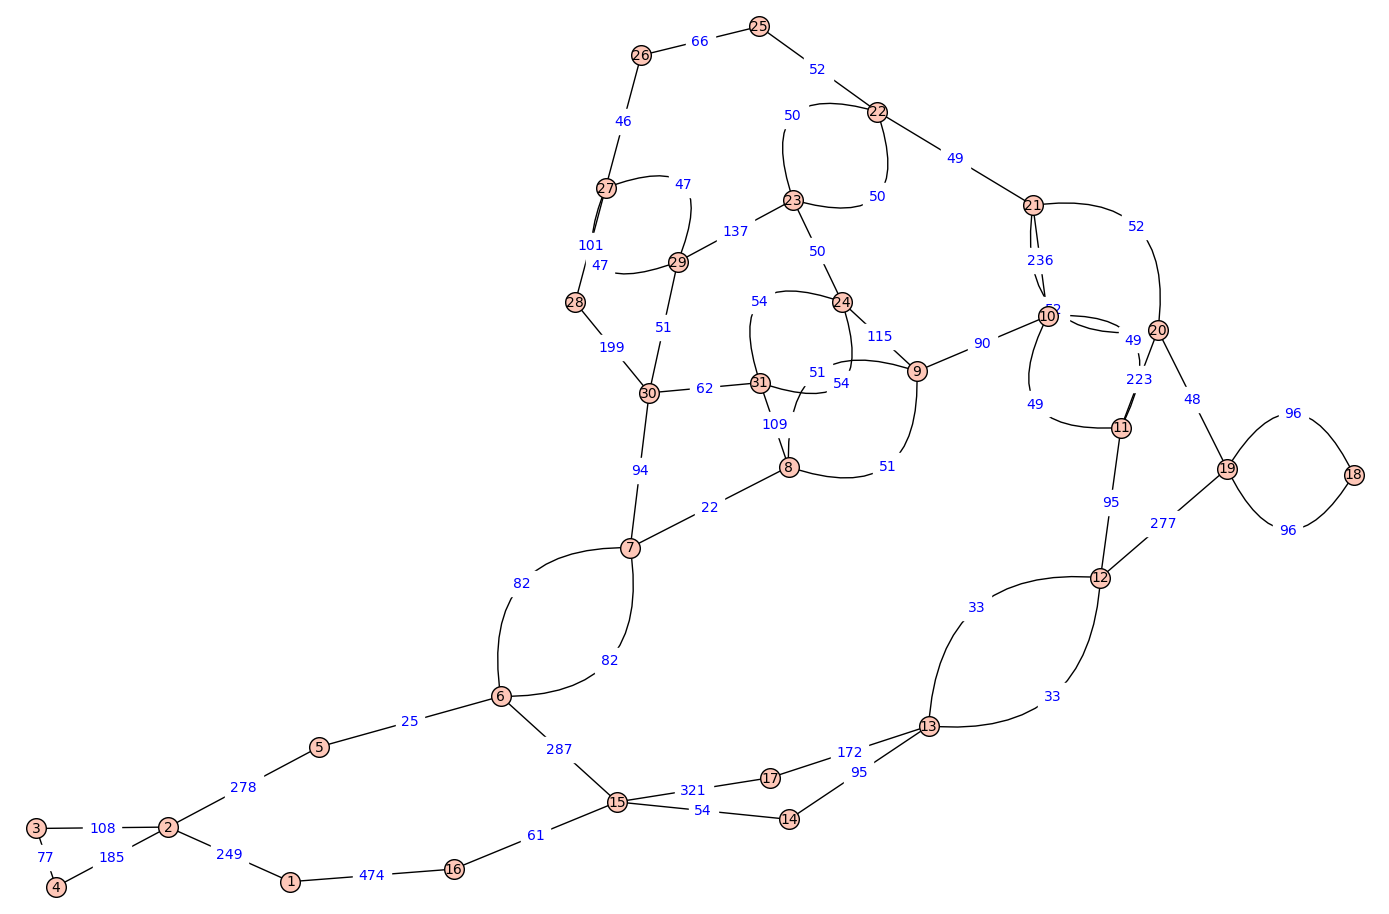

In [22]:
I.show(edge_labels=True, figsize=14)

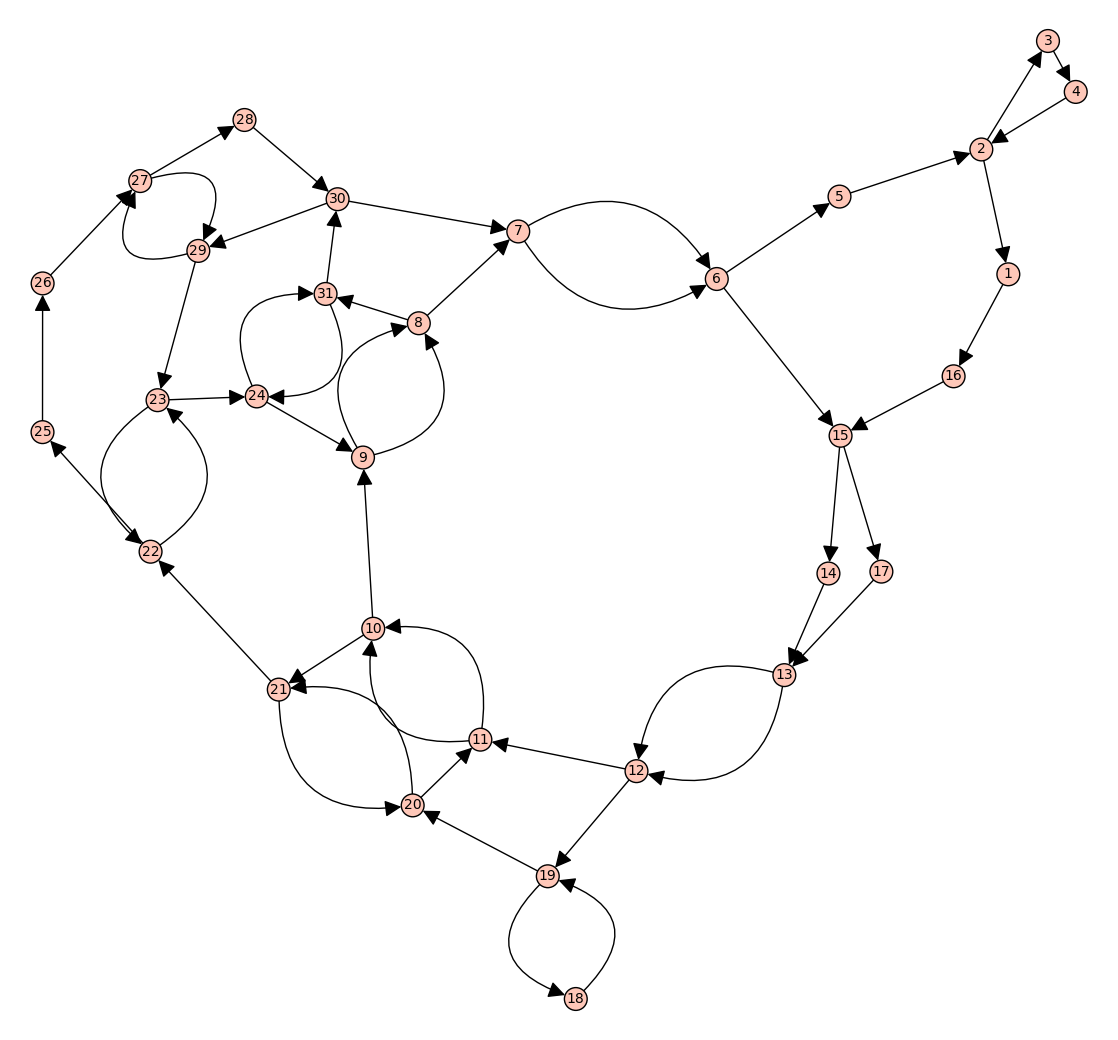

In [23]:
Eulerian = I.eulerian_orientation()
Eulerian.plot(figsize=14, vertex_size=20)